# Linear Regression


# Simple Linear Regression
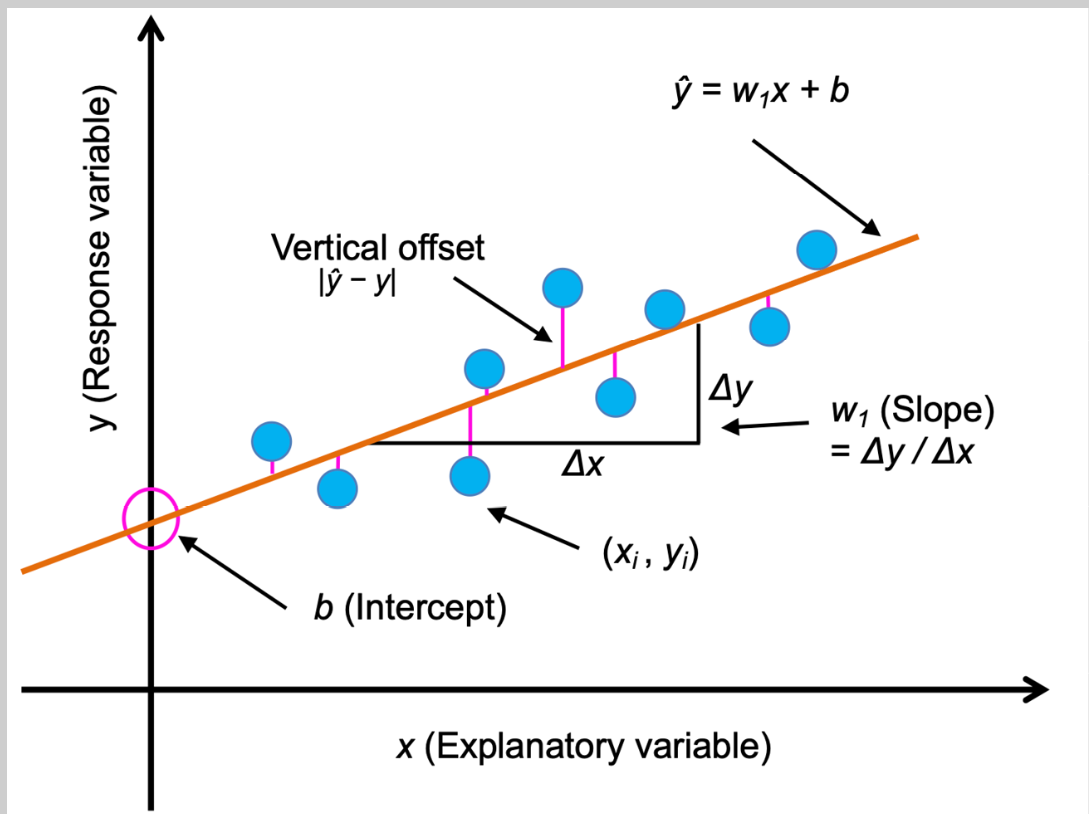

# Multiple linear regression

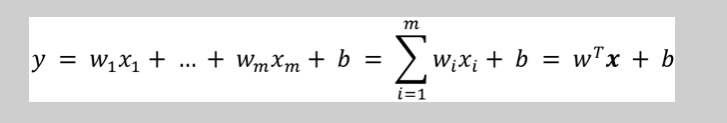

# Loading Ames Housing dataset

In [1]:
import pandas as pd

columns = ['Overall Qual', 'Overall Cond', 'Gr Liv Area', 'Central Air', 'Total Bsmt SF', 'SalePrice']

df = pd.read_csv("http://jse.amstat.org/v19n3/decock/AmesHousing.txt", sep='\t', usecols= columns)
# not that we have limit the columns for the sake of simplicity

df.head()

,Overall Qual,Overall Cond,Total Bsmt SF,Central Air,Gr Liv Area,SalePrice
0,6,5,1080.0,Y,1656,215000
1,5,6,882.0,Y,896,105000
2,6,6,1329.0,Y,1329,172000
3,7,5,2110.0,Y,2110,244000
4,5,5,928.0,Y,1629,189900


In [2]:
df["Central Air"] = df["Central Air"].map({'N':0,"Y":1})

#print(df.head())

df = df.dropna(axis= 0) # remove row
df.isnull().sum()
#print(df.head())


Overall Qual     0
Overall Cond     0
Total Bsmt SF    0
Central Air      0
Gr Liv Area      0
SalePrice        0
dtype: int64

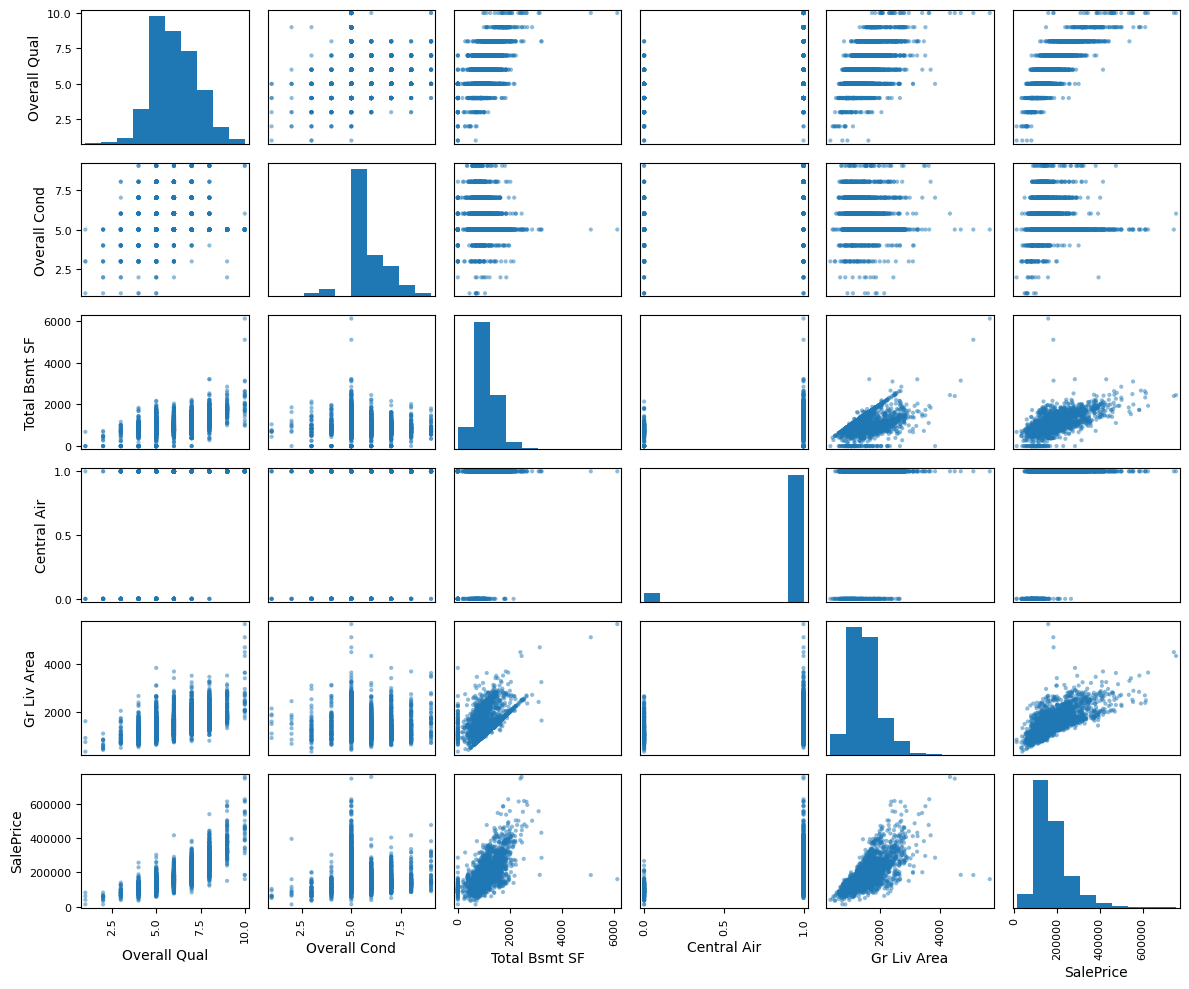

In [3]:
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

scatter_matrix(df,figsize = (12,10), alpha =0.5)
# note the figsixe is the legth inwidth and height

plt.tight_layout()
plt.show()

# note that there is a somewhat linear relationship between the size of the living area above ground (Gr Liv Area) and the sale price (SalePrice)

# Looking for correlation using Pearson product-moment correlation coefficient(r)
wherer 1 means perfect correlation while -1 is negative relation

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

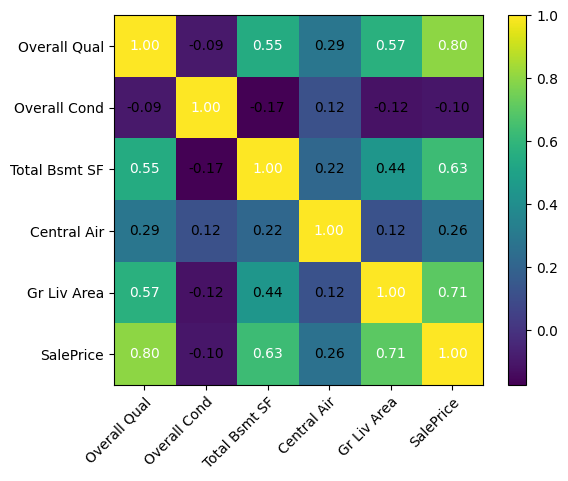

In [4]:
import numpy as np
from mlxtend.plotting import heatmap

cm = np.corrcoef(df.values.T)

hm = heatmap(cm, column_names= df.columns, row_names= df.columns)

plt.tight_layout
#note the overall qual against the sale pricr have 0.8 whle also the gr kiv against the saleprice have the 0.71

# implementing an Ordinary least squares Linear regression model

we will OLS to find the best fit line 

# Solving regression wirh gradient deviation
we will use this loss function: mse
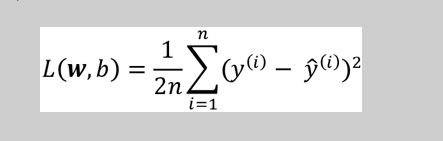

where y is the predicted values:
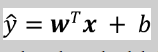



In [5]:
class LinearRegressionGD:
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state
    def fit(self, X, y):
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = np.array([0.])
        self.losses_ = []
        for i in range(self.n_iter):
            output = self.net_input(X)
            errors = (y - output)
            self.w_ += self.eta * 2.0 * X.T.dot(errors) / X.shape[0]
            self.b_ += self.eta * 2.0 * errors.mean()
            loss = (errors**2).mean()
            self.losses_.append(loss)
        return self
    def net_input(self, X):
        return np.dot(X, self.w_) + self.b_
    def predict(self, X):
        return self.net_input(X)

In [6]:
# we willuse the Gr Liv Area instead of oval  because there seems to be linear relationship between them
X = df[["Gr Liv Area"]].values
Y = df["SalePrice"].values

from sklearn.preprocessing import StandardScaler

ssc_x = StandardScaler()
ssc_y = StandardScaler()

x_std = ssc_x.fit_transform(X)
y_std = ssc_y.fit_transform(Y[:, np.newaxis]).flatten()

# not the scikit ssc xpects the  two dimensions, we them return it to normal form after transfoming it through flattern
lr = LinearRegressionGD(eta= 0.1)
lr.fit(x_std, y_std)




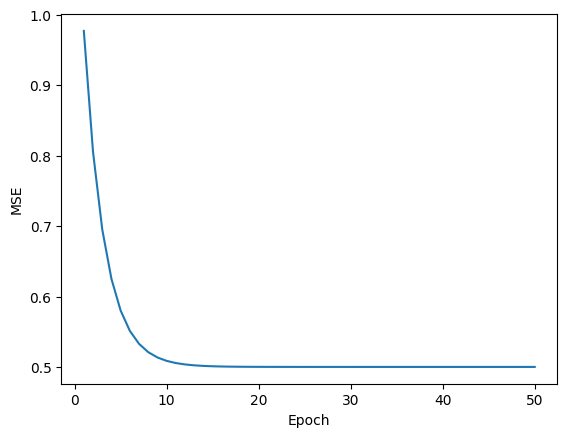

In [7]:
# plotting the mse
plt.plot(range(1, lr.n_iter+1), lr.losses_)
plt.ylabel('MSE')
plt.xlabel('Epoch')
plt.show()

In [8]:
def lin_regbook(x,y,model):
    plt.scatter(x,y,c ="red", alpha= 0.4, edgecolors= "white", s = 70)
    plt.plot(x,model.predict(x),color = "black", lw =2)

Text(0, 0.5, 'Sale price (standardized)')

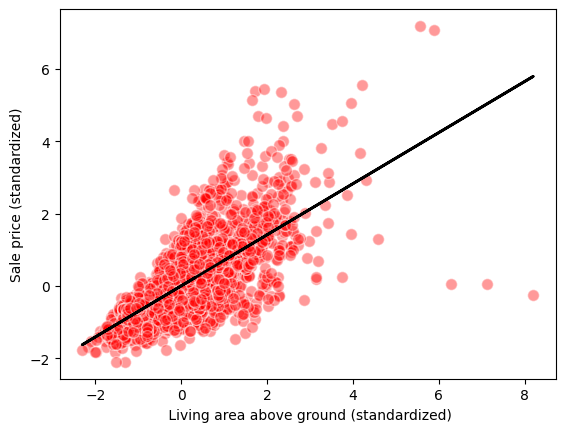

In [9]:
lin_regbook(x_std, y_std, lr)
plt.xlabel(' Living area above ground (standardized)')
plt.ylabel('Sale price (standardized)')

# coverting the predicted values to original form

In [10]:
feature_std = ssc_x.transform(np.array([[2500]]))

target_std = lr.predict(feature_std)

print(target_std)

target_norm = ssc_y.inverse_transform(target_std.reshape(-1,1))
#reshape gives it to the form it exptecs since it should be in 2d

print(target_norm)
print(target_norm.flatten())

print(f'Slope: {lr.w_[0]:.3f}')
print(f'Intercept: {lr.b_[0]:.3f}')


[1.39832089]
[[292507.06743664]]
[292507.06743664]
Slope: 0.707
Intercept: -0.000


# Estimating the coefficient of a regression model via scikit-learn

the slope is 111.666
the intercepts is13342.979


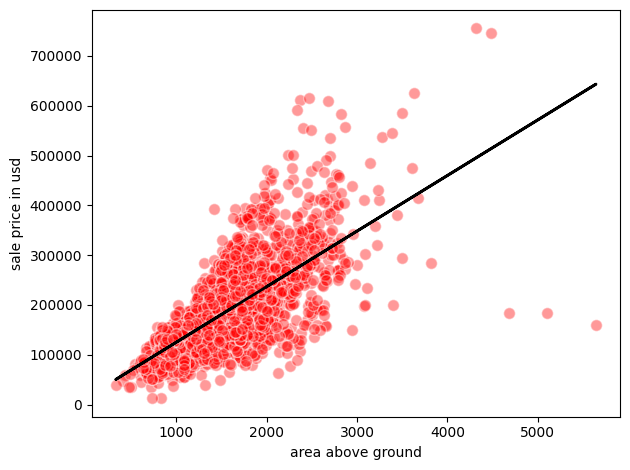

In [14]:
from sklearn.linear_model import LinearRegression

lrt = LinearRegression()
lrt.fit(X,Y)

y_pred = lrt.predict(X)
print(f"the slope is {lrt.coef_[0]:.3f}")

print(f"the intercepts is{lrt.intercept_:.3f}")
lin_regbook(X,Y, lrt)
plt.xlabel("area above ground")
plt.ylabel("sale price in usd")
plt.tight_layout()
plt.show()
